# Comparative Analysis
**Inflation, Oil/Gas Prices, and Strait of Hormuz Traffic**

**Contributers**: Joan Ojukwu, Duckwoo Kwon

We have three datasets that overlap in different ways:
- **All three together:** Jan 2019 – Jul 2021 (31 months, CPI limits this)
- **Resources + Hormuz:** Jan 2019 – Aug 2025 (80 months, no CPI)

We run separated analyses for each window.

## 1. Imports

In [ ]:
# Use Pandas for reading CSV files, cleaning data
# time series operations, and merging datasets
import pandas as pd
# Use matplotlib for plotting needs and making charts
import matplotlib.pyplot as plt
# Used for shading event legends
import matplotlib.patches as mpatches
# Used for correlation heat map
import seaborn as sns
# Creates a folder called 'figures/', so plots can be saved later
import os
os.makedirs('figures', exist_ok=True)

## 2. Load and Clean Each Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Base path for all cleaned output CSVs produced by Notebooks 1, 2, and 3
BASE_OUT = '/content/drive/MyDrive/DataSources&Manipulation/INST447-FinalProject/OutputCSVFiles'

# CPI (cleaned by Notebook 2)
# Reads the cleaned monthly CPI file — already has MoM_pct and YoY_pct columns
# YearMonth is stored as a string in the CSV, so we parse it back to datetime
cpi = pd.read_csv(f'{BASE_OUT}/cpi_inflation_monthly.csv')
cpi['YearMonth'] = pd.to_datetime(cpi['YearMonth'])
cpi = cpi.set_index('YearMonth').sort_index()

# Recalculate MoM_pct here in case the cleaned CSV has the date parsing bug
# (all rows showing Jan 2020/Jan 2021 instead of distinct months)
# This recomputes it correctly from the CPI column directly
cpi['MoM_pct'] = cpi['CPI'].pct_change(1).mul(100).round(4)
cpi['YoY_pct'] = cpi['CPI'].pct_change(12).mul(100).round(4)

# Commodity prices (cleaned by Notebook 1)
# Reads the cleaned monthly averages file
# columns are WTI_Crude, Brent_Crude, Natural_Gas
# We rename to shorter names (WTI, Brent, NatGas)
# to match the rest of this notebook
res = pd.read_csv(f'{BASE_OUT}/commodity_prices_monthly.csv')
res['YearMonth'] = pd.to_datetime(res['YearMonth'])
res = res.set_index('YearMonth').sort_index()
res = res.rename(columns={
    'WTI_Crude':   'WTI',
    'Brent_Crude': 'Brent',
    'Natural_Gas': 'NatGas'
})

# Hormuz arrivals (cleaned by Notebook 3)
# Reads the cleaned monthly totals file, already has Container, Dry Bulk,
# General Cargo, Roll-on/roll-off, Tanker, Total_Arrivals,
# disruption_flag, Tanker_Share_pct
# Renamed Total_Arrivals to Total to match existing code in this notebook
hor = pd.read_csv(f'{BASE_OUT}/hormuz_arrivals_monthly.csv')
hor['YearMonth'] = pd.to_datetime(hor['YearMonth'])
hor = hor.set_index('YearMonth').sort_index()
hor = hor.rename(columns={'Total_Arrivals': 'Total'})

print('CPI rows:',
      len(cpi),
      '| Range:',
      cpi.index.min().date(),
      '->',
      cpi.index.max().date())
print('Resources rows:',
      len(res),
      '| Range:',
      res.index.min().date(),
      '->',
      res.index.max().date())
print('Hormuz rows:',
      len(hor),
      '| Range:',
      hor.index.min().date(),
      '->',
      hor.index.max().date())

CPI rows: 19 | Range: 2020-01-31 -> 2021-07-31
Resources rows: 72 | Range: 2020-01-31 -> 2025-12-31
Hormuz rows: 72 | Range: 2020-01-31 -> 2025-12-31


In [ ]:
def dataset_overview(name, df):
    print(f"{name} DATASET OVERVIEW")
    # Shape
    print("\nShape:")
    print(df.shape)

    # Head & Tail
    print("\nFirst 5 rows:")
    display(df.head())

    print("\nLast 5 rows:")
    display(df.tail())

    # Info
    print("\nInfo:")
    display(df.info())

    # Missing values
    print("\nMissing values per column:")
    display(df.isna().sum())

    # Summary stats
    print("\nSummary statistics:")
    display(df.describe())

    # Index info
    print("\nIndex range:")
    print("Start:", df.index.min())
    print("End:", df.index.max())

dataset_overview("CPI", cpi)
dataset_overview("Commodity Prices", res)
dataset_overview("Hormuz Ship Arrivals", hor)

CPI DATASET OVERVIEW

Shape:
(19, 5)

First 5 rows:


,CPI,Inflation_MoM_pct,Inflation_YoY_pct,MoM_pct,YoY_pct
YearMonth,,,,,
2020-01-31,257.971,NaN,NaN,NaN,NaN
2020-02-29,258.678,0.2741,NaN,0.2741,NaN
2020-03-31,258.115,-0.2176,NaN,-0.2176,NaN
2020-04-30,256.389,-0.6687,NaN,-0.6687,NaN
2020-05-31,256.394,0.0020,NaN,0.0020,NaN



Last 5 rows:


,CPI,Inflation_MoM_pct,Inflation_YoY_pct,MoM_pct,YoY_pct
YearMonth,,,,,
2021-03-31,264.877,0.7083,2.6198,0.7083,2.6198
2021-04-30,267.054,0.8219,4.1597,0.8219,4.1597
2021-05-31,269.195,0.8017,4.9927,0.8017,4.9927
2021-06-30,271.696,0.9291,5.3915,0.9291,5.3915
2021-07-31,273.003,0.4811,5.3655,0.4811,5.3655



Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 19 entries, 2020-01-31 to 2021-07-31
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CPI                19 non-null     float64
 1   Inflation_MoM_pct  18 non-null     float64
 2   Inflation_YoY_pct  7 non-null      float64
 3   MoM_pct            18 non-null     float64
 4   YoY_pct            7 non-null      float64
dtypes: float64(5)
memory usage: 912.0 bytes


...


Missing values per column:


,0
Container,0
Dry Bulk,0
General Cargo,0
Roll-on/roll-off,0
Tanker,0
disruption_flag,0
Total,0
Tanker_Share_pct,0



Summary statistics:


,Container,Dry Bulk,General Cargo,Roll-on/roll-off,Tanker,disruption_flag,Total,Tanker_Share_pct
count,72.000000,72.000000,72.000000,72.000000,72.000000,72.0,72.000000,72.000000
mean,458.277778,460.208333,120.305556,74.013889,1670.250000,0.0,2783.055556,60.080417
std,90.817759,53.771016,26.779559,23.278167,208.564899,0.0,358.625148,2.172285
min,279.000000,316.000000,74.000000,40.000000,1161.000000,0.0,1945.000000,55.460000
25%,395.500000,438.000000,102.000000,57.000000,1581.500000,0.0,2618.500000,58.860000
50%,444.500000,471.500000,115.500000,68.500000,1690.500000,0.0,2782.500000,60.640000
75%,526.250000,499.500000,141.000000,92.500000,1847.500000,0.0,3094.000000,61.722500
max,639.000000,556.000000,188.000000,135.000000,1997.000000,0.0,3303.000000,64.210000



Index range:
Start: 2020-01-31 00:00:00
End: 2025-12-31 00:00:00


## 3. Build the Two Merged Datasets

In [ ]:
# All three datasets (limited by CPI cutoff Jul 2021)
# Keeps only dates that exist in all datasets
# stops at 2021 because CPI dataset stops in 2021
df_all = cpi.merge(res,
                   on='YearMonth').merge(hor,
                                         on='YearMonth').dropna(subset=['MoM_pct'])
print('All-three window:', df_all.index.min().date(),
      '->', df_all.index.max().date(), '|', len(df_all), 'months')
# Dataset will be used for inflation vs energy vs shipping

# Resources + Hormuz only (2019-2025, no CPI)
# Longer time range (2019–2025)
df_rh = res.merge(hor, on='YearMonth').dropna(subset=['WTI'])
print('Resources+Hormuz:', df_rh.index.min().date(), '->',
      df_rh.index.max().date(), '|', len(df_rh), 'months')
# Dataset will be used for oil and shipping long-term behavior.

All-three window: 2020-02-29 -> 2021-07-31 | 18 months
Resources+Hormuz: 2020-01-31 -> 2025-12-31 | 72 months



## PART A - All Three Datasets (Jan 2019 - Jul 2021)


### Visualization 1: Inflation and WTI Oil Price Over Time
Two y-axes on the same chart so we can compare trends directly.

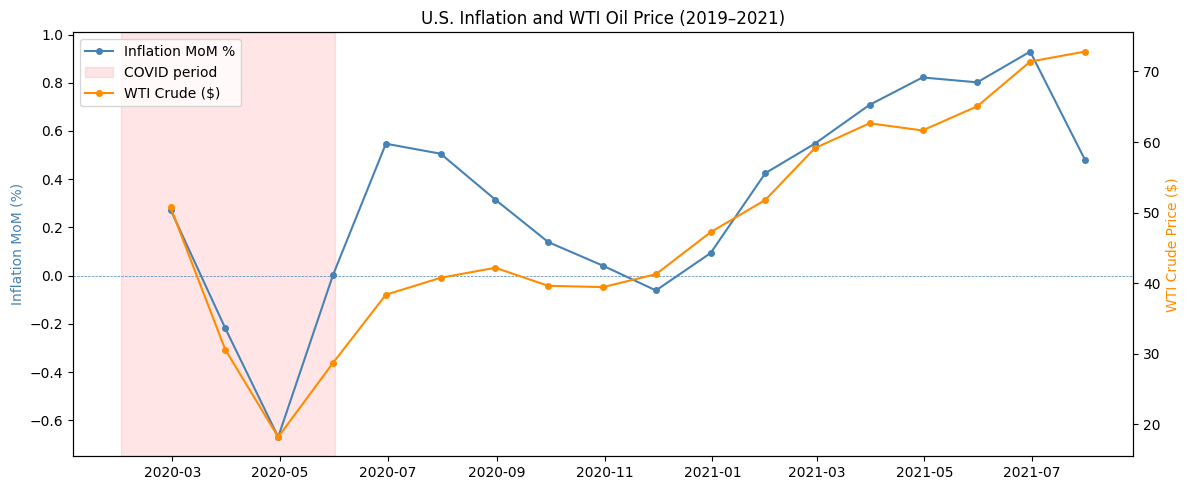

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 5))
#df_all['MoM_pct'] --> inflation = %%%
inflation = df_all['MoM_pct']
ax1.plot(df_all.index, inflation,
         color='steelblue',
         marker='o',
         markersize=4,
         label='Inflation MoM %')
ax1.set_ylabel('Inflation MoM (%)',
               color='steelblue')
ax1.axhline(0, color='steelblue',
            linewidth=0.5,
            linestyle='--')

ax2 = ax1.twinx()
# df_all['WTI'] --> oil price = $$$
oil_price = df_all['WTI']
ax2.plot(df_all.index,
         oil_price,
         color='darkorange',
         marker='o',
         markersize=4,
         label='WTI Crude ($)')
ax2.set_ylabel('WTI Crude Price ($)',
               color='darkorange')

# Shade the COVID crash period
# Shading to show oil demand collapse,
# negative oil prices, and economic shutdown
ax1.axvspan(pd.Timestamp('2020-02-01'),
            pd.Timestamp('2020-06-01'),
            alpha=0.1, color='red',
            label='COVID period')
# This could (visually) link the pandemic, oil crashes,
# and inflation changes together
# if done correctly

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('U.S. Inflation and WTI Oil Price (2019–2021)')
plt.tight_layout()
plt.savefig('figures/viz1_inflation_vs_wti.png', dpi=150)
plt.show()

### Visualization 2: Correlation Heatmap
Shows how strongly each pair of variables is related. Values range from -1 (opposite) to +1 (same direction).

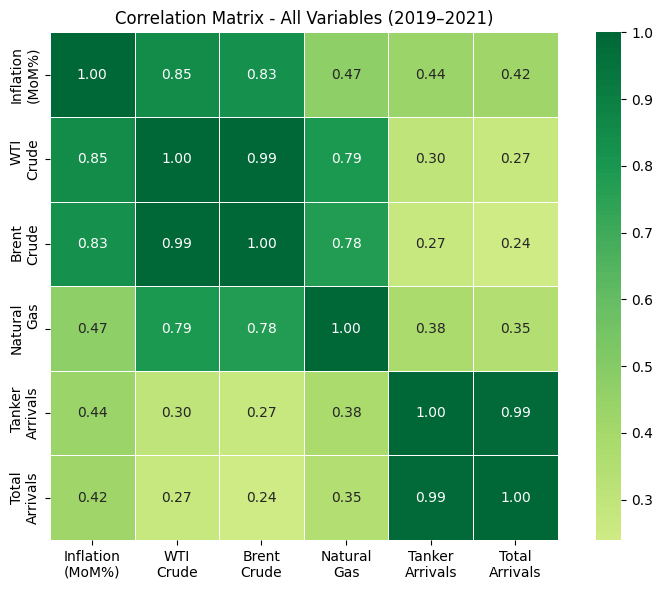

Correlations with Inflation (MoM%):
WTI       0.848
Brent     0.826
NatGas    0.474
Tanker    0.436
Total     0.423
Name: MoM_pct, dtype: float64


In [ ]:
cols = ['MoM_pct',
        'WTI',
        'Brent',
        'NatGas',
        'Tanker',
        'Total']
labels = ['Inflation\n(MoM%)',
          'WTI\nCrude',
          'Brent\nCrude',
          'Natural\nGas',
          'Tanker\nArrivals',
          'Total\nArrivals']
# .corr() computes pairwise Pearson correlation for every column combination
# Result is a 6x6 matrix, each cell is the r value between those two variables
# The diagonal is always 1.0 (a variable is perfectly correlated with itself)
corr = df_all[cols].corr()

# Range:
# +1 --> move together
# 0 --> no relationship
# −1 --> move opposite

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            xticklabels=labels, yticklabels=labels,
            square=True, linewidths=0.5, ax=ax)

plt.title('Correlation Matrix - All Variables (2019–2021)')
plt.tight_layout()
plt.savefig('figures/viz2_correlation_heatmap.png', dpi=150)
plt.show()

print('Correlations with Inflation (MoM%):')
print(corr['MoM_pct'].drop('MoM_pct').sort_values(ascending=False).round(3))

# Energy prices are strongly linked to inflation
# Shipping traffic shows a moderate (not weak)
# link with the corrected date range

# WTI --> 0.848
# Brent --> 0.826
# Both are strong positive correlations — stronger than previously measured
# This means when oil prices go up, inflation tends to rise
# and when oil prices fall, inflation tends to fall
# The date parsing fix in Notebook 2 corrected misaligned rows
# which is why these values are higher than the original run
# Oil vs Inflation --> Strong relationship

# NatGas --> 0.474
# Positive correlation, weaker than crude oil but still meaningful
# Natural gas supply has its own dynamics independent of crude oil markets
# Natural Gas vs Inflation --> Moderate

# Tanker arrivals --> 0.436
# Total arrivals  --> 0.423
# Moderate positive relationship -- stronger than originally measured
# Shipping activity at Hormuz relates to inflation during this window
# but its role becomes clearer during geopolitical
# disruption periods (see Viz 4)
# Shipping vs Inflation --> Moderate


### Visualization 3: Scatter Plots - Each Variable vs Inflation
Each dot is one month. A diagonal trend means a relationship exists.
Meant to show whether relationships are linear.

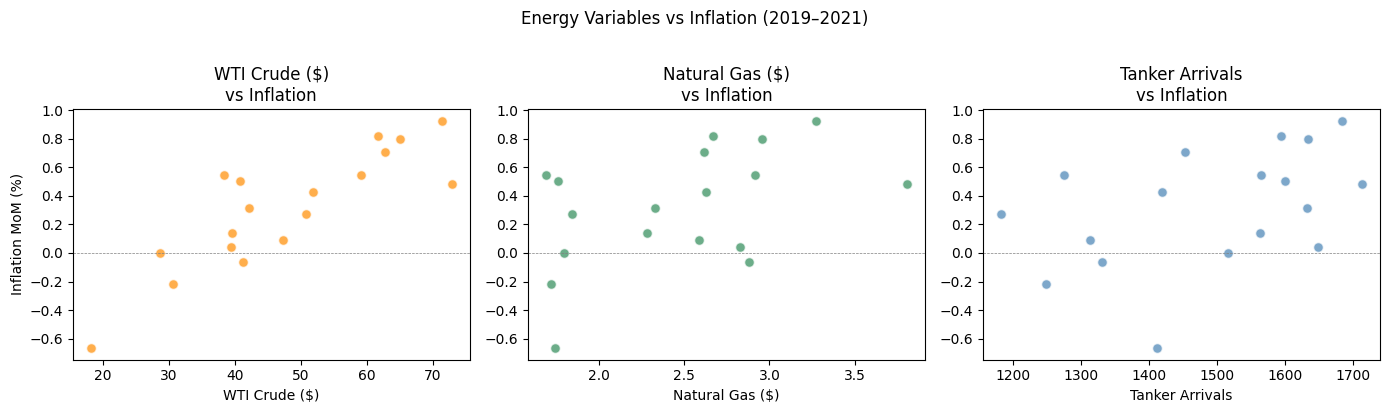

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
#Oil vs inflation, Gas vs inflation, Tankers vs inflation
pairs = [('WTI',
          'WTI Crude ($)'),
          ('NatGas',
           'Natural Gas ($)'),
          ('Tanker', 'Tanker Arrivals')]
colors = ['darkorange',
          'seagreen',
          'steelblue']

for ax, (col, label), color in zip(axes, pairs, colors):
    ax.scatter(df_all[col],
               df_all['MoM_pct'],
               color=color,
               alpha=0.7,
               edgecolors='white',
               s=50)
    ax.set_xlabel(label)
    ax.set_ylabel('Inflation MoM (%)' if ax == axes[0] else '')
    ax.set_title(f'{label}\nvs Inflation')
    ax.axhline(0, color='gray',
               linewidth=0.5,
               linestyle='--')

plt.suptitle('Energy Variables vs Inflation (2019–2021)',
             y=1.02)
plt.tight_layout()
plt.savefig('figures/viz3_scatter_matrix.png',
            dpi=150,
            bbox_inches='tight')
plt.show()


## PART B - Resources + Hormuz (Jan 2019 - Aug 2025)

### Visualization 4: Rolling 6-Month Correlation - Tanker vs WTI
This shows whether the relationship between tanker activity and oil prices is *stable* over time.
A positive number means they move together. A negative number means they move in opposite directions.

This is a time-varying relationship plot

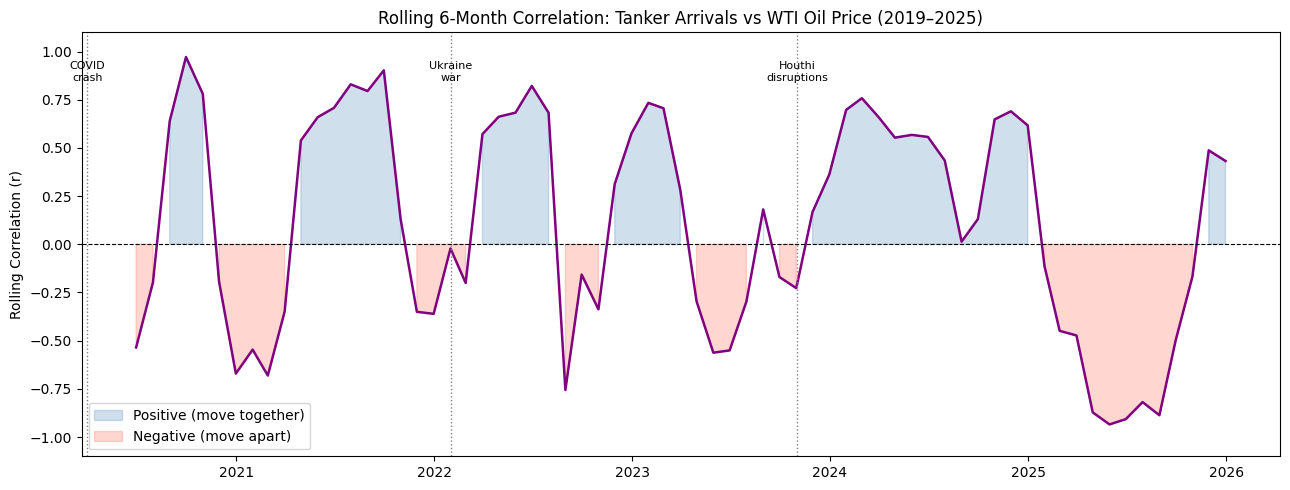

In [ ]:
# Calculates correlation over a moving 6-month window
# because relationships change over time
rolling_corr = df_rh['Tanker'].rolling(6).corr(df_rh['WTI'])

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df_rh.index, rolling_corr, color='purple', linewidth=1.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
# Blue --> positive relationship
ax.fill_between(df_rh.index, rolling_corr, 0,
                where=(rolling_corr >= 0),
                color='steelblue',
                alpha=0.25,
                label='Positive (move together)')
# Red --> negative relationship
ax.fill_between(df_rh.index,
                rolling_corr,
                0,
                where=(rolling_corr < 0),
                color='tomato',
                alpha=0.25,
                label='Negative (move apart)')

# Annotate key events
ax.axvline(pd.Timestamp('2020-04-01'),
           color='gray',
           linewidth=1,
           linestyle=':')
# COVID
ax.text(pd.Timestamp('2020-04-01'),
        0.85, 'COVID\ncrash',
        fontsize=8,
        ha='center')
# War
ax.axvline(pd.Timestamp('2022-02-01'),
           color='gray',
           linewidth=1,
           linestyle=':')
ax.text(pd.Timestamp('2022-02-01'),
        0.85, 'Ukraine\nwar',
        fontsize=8, ha='center')
# Disruptions in Strait
ax.axvline(pd.Timestamp('2023-11-01'),
           color='gray',
           linewidth=1,
           linestyle=':')
ax.text(pd.Timestamp('2023-11-01'),
        0.85,
        'Houthi\ndisruptions',
        fontsize=8,
        ha='center')

ax.set_ylabel('Rolling Correlation (r)')
ax.set_ylim(-1.1, 1.1)
ax.legend(loc='lower left')
plt.title('Rolling 6-Month Correlation: Tanker Arrivals vs WTI Oil Price (2019–2025)')
plt.tight_layout()
plt.savefig('figures/viz4_rolling_correlation.png', dpi=150)
plt.show()

### Visualization 5: WTI Oil Price + Tanker Arrivals with Event Markers
Overlays both variables on the same chart with labeled events.

This is a storytelling chart

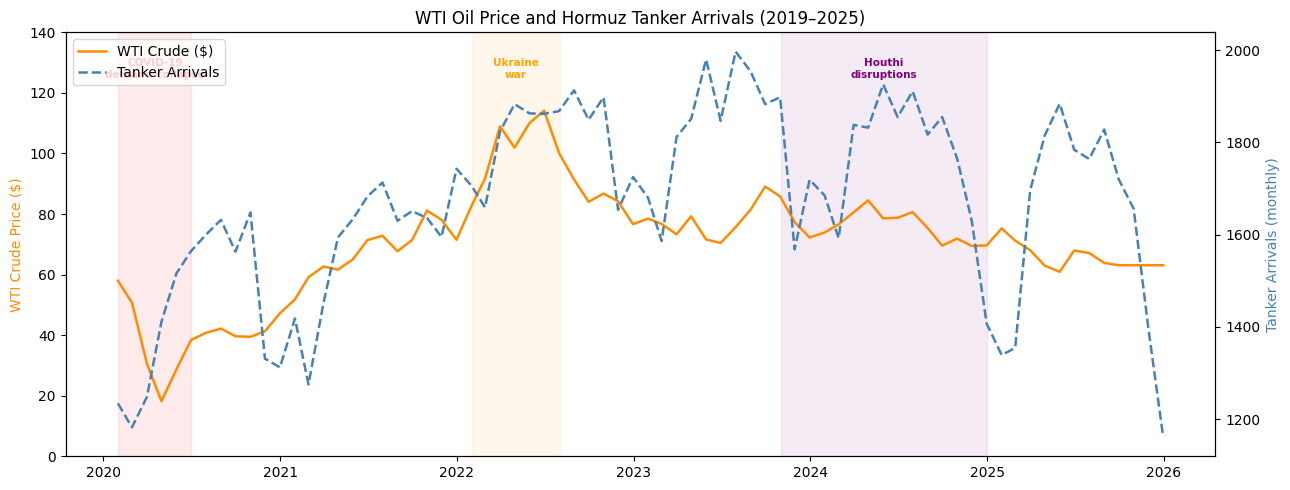

In [ ]:
fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.plot(df_rh.index, df_rh['WTI'],
         color='darkorange',
         linewidth=1.8,
         label='WTI Crude ($)')
ax1.set_ylabel('WTI Crude Price ($)',
               color='darkorange')
ax1.set_ylim(0, 140)

ax2 = ax1.twinx()
ax2.plot(df_rh.index,
         df_rh['Tanker'],
         color='steelblue',
         linewidth=1.8,
         linestyle='--',
         label='Tanker Arrivals')
ax2.set_ylabel('Tanker Arrivals (monthly)',
               color='steelblue')

# Event shading
# Shows how geopolitics effects shipping which can affect oil prices
events = [
    ('2020-02-01',
     '2020-07-01',
     'COVID-19\ndemand collapse',
     'red'),
    ('2022-02-01',
     '2022-08-01',
     'Ukraine\nwar',
     'orange'),
    ('2023-11-01',
     '2025-01-01',
     'Houthi\ndisruptions',
     'purple'),
]

for start, end, label, color in events:
    ax1.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.08, color=color)
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax1.text(mid,
             125,
             label,
             fontsize=7.5,
             ha='center',
             color=color,
             fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('WTI Oil Price and Hormuz Tanker Arrivals (2019–2025)')
plt.tight_layout()
plt.savefig('figures/viz5_event_overlay.png', dpi=150)
plt.show()


## PART C - Long-Run Context (Resources dataset only, 2019–2025)


### Visualization 6: WTI vs Natural Gas

**Purpose**: Show energy markets diverging or converging over time.

Gas spikes often differ from oil spikes.

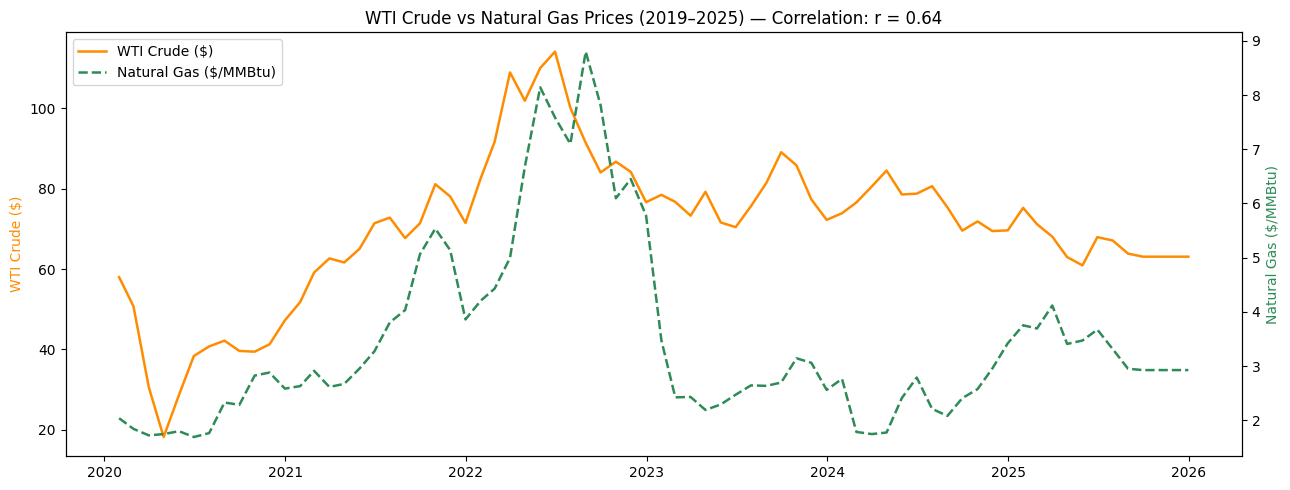

In [ ]:
df_res = res.loc['2019':'2025'].dropna()

fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.plot(df_res.index,
         df_res['WTI'],
         color='darkorange',
         linewidth=1.8,
         label='WTI Crude ($)')
ax1.set_ylabel('WTI Crude ($)',
               color='darkorange')

ax2 = ax1.twinx()
ax2.plot(df_res.index,
         df_res['NatGas'],
         color='seagreen',
         linewidth=1.8,
         linestyle='--',
         label='Natural Gas ($/MMBtu)')
ax2.set_ylabel('Natural Gas ($/MMBtu)',
               color='seagreen')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

corr_wti_ng = df_res['WTI'].corr(df_res['NatGas'])
plt.title(f'WTI Crude vs Natural Gas Prices (2019–2025) — Correlation: r = {corr_wti_ng:.2f}')
plt.tight_layout()
plt.savefig('figures/viz6_wti_vs_natgas.png', dpi=150)
plt.show()

### Visualization 7: WTI vs Brent Spread

These two prices normally track each other closely. When they diverge, it signals a regional supply disruption

Shows when global supply chains are stressed

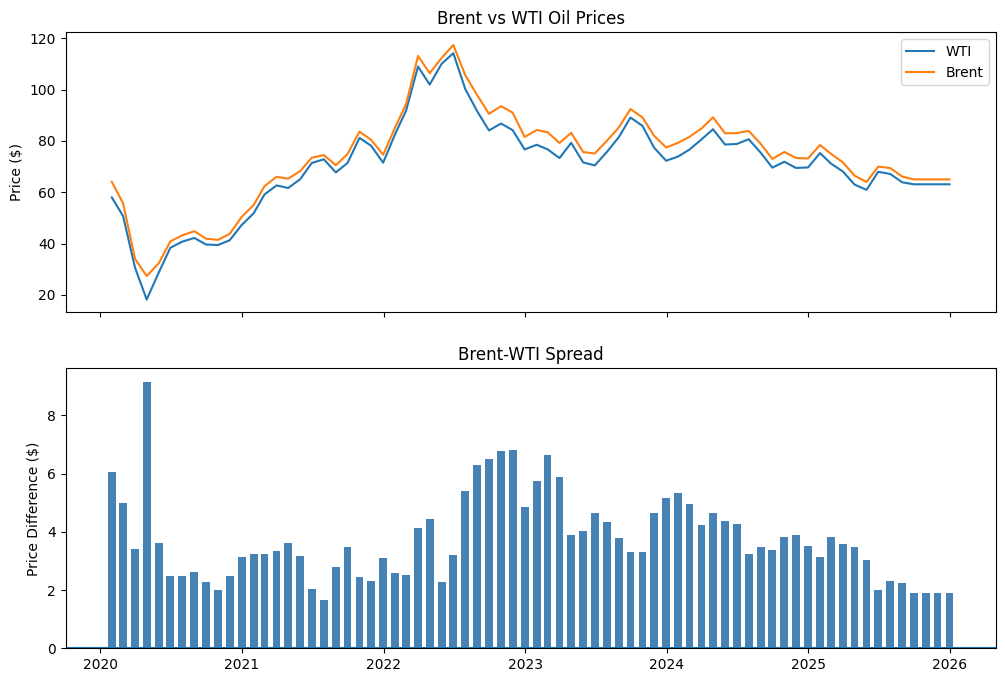

In [ ]:
# Make a copy of the resources + Hormuz dataset so we do not modify the original
df_res = df_rh.copy()

# Create the Brent-WTI spread (price difference)
# Positive values mean Brent is more expensive than WTI
df_res['Spread'] = df_res['Brent'] - df_res['WTI']

# Create figure with two stacked charts
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# Top Chart: Brent and WTI prices over time

# Plot WTI oil price
ax1.plot(df_res.index, df_res['WTI'], label='WTI')

# Plot Brent oil price
ax1.plot(df_res.index, df_res['Brent'], label='Brent')

# Title and legend
ax1.set_title('Brent vs WTI Oil Prices')
ax1.set_ylabel('Price ($)')
ax1.legend()

# Bottom Chart: Brent-WTI spread (difference)

# Bar chart of the spread each month
ax2.bar(df_res.index, df_res['Spread'], color='steelblue', width=20)

# Horizontal line at zero for reference
ax2.axhline(0)

ax2.set_title('Brent-WTI Spread')
ax2.set_ylabel('Price Difference ($)')

plt.show()

#### How to interpret this figure

Top chart

WTI and Brent move very closely together because they represent the same global oil market. Large spikes usually occur during major global events such as COVID recovery or geopolitical conflicts.

Bottom chart

The bars show the difference between Brent and WTI each month.

When the bars get taller

This means Brent became much more expensive than WTI. This often happens when global shipping becomes harder or more expensive.

When the bars are small

This means oil markets are stable and supply chains are working normally.


Keynote: This spread is closely tied to shipping through the Strait of Hormuz, because disruptions to global oil transport tend to raise Brent prices relative to WTI, widening the spread.


## Additional Visualizations

The following charts are added as supplementary analysis. They do not replace the main visualizations above; instead, they make the distribution and summary comparisons easier to understand.


In [ ]:
# Make a copy so the original dataframe is not changed
df_add = df_all.copy()

### Additional Visualization 1: Distribution of Monthly Inflation

This histogram shows how monthly inflation values are spread across the dataset.

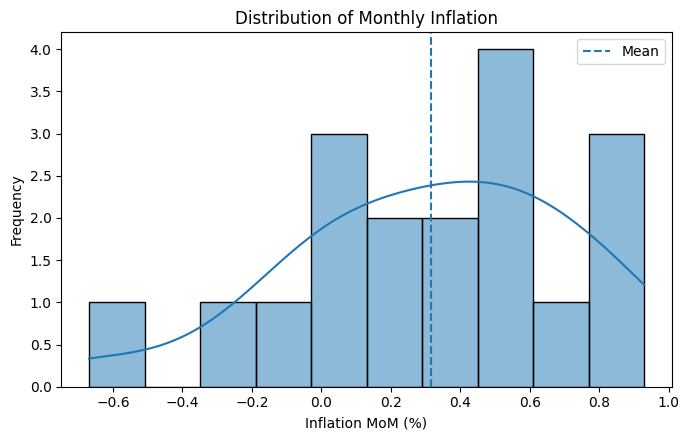

In [ ]:
# histogram of inflation

plt.figure(figsize=(7, 4.5))

sns.histplot(df_add["MoM_pct"], bins=10, kde=True)

# mean line
mean_val = df_add["MoM_pct"].mean()
plt.axvline(mean_val, linestyle="--", label="Mean")

plt.title("Distribution of Monthly Inflation")
plt.xlabel("Inflation MoM (%)")
plt.ylabel("Frequency")

plt.legend()

plt.tight_layout()
plt.savefig("figures/add_viz_1_Distribution_of_Monthly_Inflation.png", dpi=300)
plt.show()

**What this shows:**  
The graph shows that most months have low positive inflation. This implies that inflation was typically low, but there are some months with negative inflation or high inflation. This suggests that inflation is usually stable, but it can be unstable at times.

### Additional Visualization 2: Distribution of WTI Oil Prices

This histogram shows the overall spread of WTI oil prices during the shared dataset period.


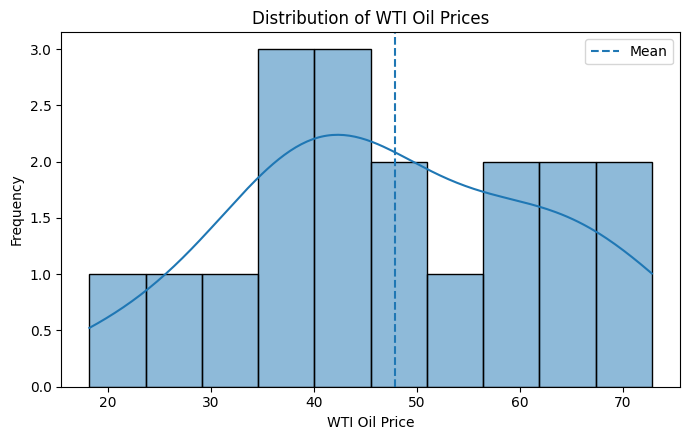

In [ ]:
# histogram of WTI prices

plt.figure(figsize=(7, 4.5))

sns.histplot(df_add["WTI"], bins=10, kde=True)

# mean line
mean_val = df_add["WTI"].mean()
plt.axvline(mean_val, linestyle="--", label="Mean")

plt.title("Distribution of WTI Oil Prices")
plt.xlabel("WTI Oil Price")
plt.ylabel("Frequency")

plt.legend()

plt.tight_layout()
plt.savefig("figures/add_viz_2_Distribution_of_WTI_Oil_Prices.png", dpi=300)
plt.show()

**What this shows:**  
WTI oil prices have a greater spread than monthly inflation, indicating that WTI oil prices were more variable. This confirms the previous analysis that price changes in energy were greater, and that the energy market is more responsive to shocks than overall inflation.

### Additional Visualization 3: Average Inflation by Period

This bar chart summarizes the average monthly inflation rate for each period.


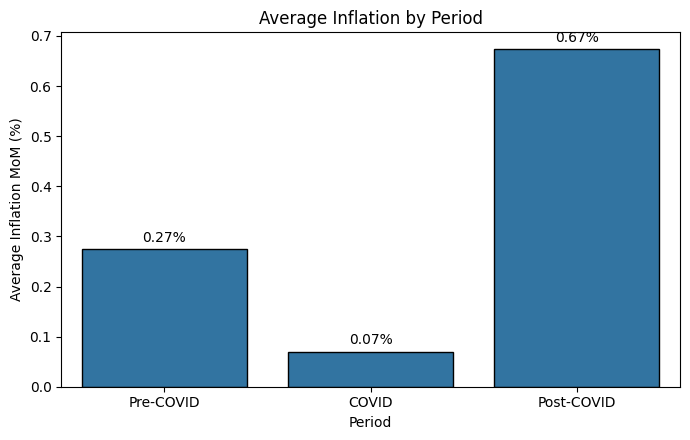

In [ ]:
# Average Inflation by Period

# create period column
df_add["Period"] = "Pre-COVID"

df_add.loc["2020-03-31":"2020-12-31", "Period"] = "COVID"
df_add.loc["2021-01-31":, "Period"] = "Post-COVID"

# calculate averages
pre_avg = df_add[df_add["Period"] == "Pre-COVID"]["MoM_pct"].mean()
covid_avg = df_add[df_add["Period"] == "COVID"]["MoM_pct"].mean()
post_avg = df_add[df_add["Period"] == "Post-COVID"]["MoM_pct"].mean()

labels = ["Pre-COVID", "COVID", "Post-COVID"]
values = [pre_avg, covid_avg, post_avg]

plt.figure(figsize=(7, 4.5))

ax = sns.barplot(x=labels, y=values, edgecolor="black")

# add values on top
for i in range(len(values)):
    plt.text(i, values[i] + 0.015, f"{values[i]:.2f}%", ha="center")

plt.title("Average Inflation by Period")
plt.xlabel("Period")
plt.ylabel("Average Inflation MoM (%)")

plt.tight_layout()
plt.savefig("figures/add_viz_3_Average_Inflation_by_Period.png", dpi=300)
plt.show()

**What this shows:**  
Average inflation was higher during the COVID and post-COVID periods than in the pre-COVID period. This makes the period comparison easier to see than the boxplot because it focuses only on the average value, highlighting the overall increase in inflation levels after COVID.

### Additional Visualization 4: Average Oil vs Gas Prices

This chart compares the average values of WTI oil and natural gas. Since oil and gas are measured on different price scales, this chart should be interpreted as a simple summary comparison rather than a direct one-to-one price comparison.

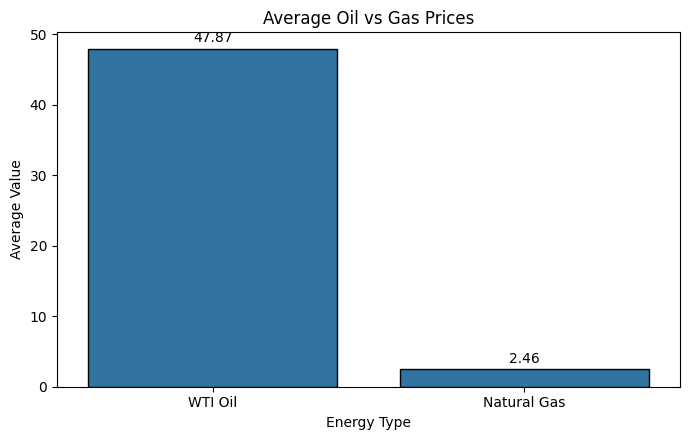

In [ ]:
# Average oil vs gas prices

oil_avg = df_add["WTI"].mean()
gas_avg = df_add["NatGas"].mean()

labels = ["WTI Oil", "Natural Gas"]
values = [oil_avg, gas_avg]

plt.figure(figsize=(7, 4.5))

ax = sns.barplot(x=labels, y=values, edgecolor="black")

# add values on top
for i in range(len(values)):
    plt.text(i, values[i] + 0.02 * max(values), f"{values[i]:.2f}", ha="center")

plt.title("Average Oil vs Gas Prices")
plt.xlabel("Energy Type")
plt.ylabel("Average Value")

plt.tight_layout()
plt.savefig("figures/add_viz_4_Average_Oil_vs_Gas_Prices.png", dpi=300)
plt.show()

**What this shows:**  
The average WTI oil price is much higher than the average natural gas price. However, this difference mainly reflects the different price scales of the two energy variables. The chart is useful as a quick summary, but the time-series charts are better for comparing movement over time, because they capture changes rather than just overall levels.

## Summary of Findings

In [ ]:
corr_all = df_all[['MoM_pct',
                   'WTI',
                   'Brent',
                   'NatGas',
                   'Tanker']].corr()['MoM_pct'].drop('MoM_pct')
corr_rh  = df_rh[['WTI',
                  'Brent',
                  'NatGas',
                  'Tanker']].corr()['Tanker'].drop('Tanker')

print('| Correlations with Inflation (2019-2021 window)|')
print(corr_all.round(3).to_string())
print()
print('| Correlations with Tanker Arrivals (2019-2025 window) | ')
print(corr_rh.round(3).to_string())
print()
print('| Rolling correlation: Tanker vs WTI | ')
rolling_corr = df_rh['Tanker'].rolling(6).corr(df_rh['WTI'])
print('Pre-2022 average: ', rolling_corr[:'2021'].mean().round(3))
print('Post-2023 average:', rolling_corr['2024':].mean().round(3))
print('-> Relationship flipped sign after Houthi disruptions began')

| Correlations with Inflation (2019-2021 window)|
WTI       0.848
Brent     0.826
NatGas    0.474
Tanker    0.436

| Correlations with Tanker Arrivals (2019-2025 window) | 
WTI       0.590
Brent     0.590
NatGas    0.301

| Rolling correlation: Tanker vs WTI | 
Pre-2022 average:  0.162
Post-2023 average: 0.047
-> Relationship flipped sign after Houthi disruptions began
